<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [5]:
# Load the dataset: try remote, fall back to local sample
remote = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
local = 'survey-duplicates.csv'
import os
try:
    df = pd.read_csv(remote)
    print('Loaded remote dataset')
except Exception as e:
    print(f'Could not load remote dataset ({e}). Using local fallback {local}')
    df = pd.read_csv(local)

# Display the first few rows and shape
print('\nFirst 5 rows:')
print(df.head())
print('\nDataset shape:', df.shape)


Could not load remote dataset (<urlopen error [Errno 11002] getaddrinfo failed>). Using local fallback survey-duplicates.csv

First 5 rows:
   RespondentID            MainBranch          Employment  \
0             1          Data science  Employed full-time   
1             2          Data science  Employed full-time   
2             3          Data science  Employed part-time   
3             4  Software development  Employed full-time   
4             5          Data science  Employed full-time   

                RemoteWork Country              Age  YearsCode  \
0  Less than half the time     USA  25-34 years old          3   
1  Less than half the time     USA  25-34 years old          3   
2  More than half the time  Canada  18-24 years old          1   
3             All the time   India  25-34 years old          5   
4  Less than half the time     USA  25-34 years old          3   

             EdLevel  
0    Master's degree  
1    Master's degree  
2  Bachelor's degree  
3  B

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [ ]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [6]:
# Task 1: Identify duplicate rows
total_duplicates = df.duplicated().sum()
print('Total duplicate rows (exact duplicates):', total_duplicates)
# Show first few duplicate rows (keep=False shows all occurrences)
dups = df[df.duplicated(keep=False)]
print('\nSample duplicate rows:')
print(dups.head())


Total duplicate rows (exact duplicates): 0

Sample duplicate rows:
Empty DataFrame
Columns: [RespondentID, MainBranch, Employment, RemoteWork, Country, Age, YearsCode, EdLevel]
Index: []


### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [7]:
# Task 2: Analysis of duplicate response patterns
# Define response-pattern columns
pattern_cols = ['MainBranch','Employment','RemoteWork']
pattern_counts = df.groupby(pattern_cols).size().reset_index(name='count')
# Show patterns that occur more than once
shared_patterns = pattern_counts[pattern_counts['count'] > 1].sort_values('count', ascending=False)
print('Response patterns occurring more than once:')
print(shared_patterns)
# For those patterns, inspect which other columns are identical
if not shared_patterns.empty:
    print('\nInspect rows for the top repeated pattern:')
    top = shared_patterns.iloc[0][pattern_cols].to_dict()
    mask = (df[pattern_cols] == pd.Series(top)).all(axis=1)
    print(df[mask])


Response patterns occurring more than once:
             MainBranch          Employment               RemoteWork  count
1          Data science  Employed full-time  Less than half the time      4
0      Data engineering  Employed full-time             All the time      2
2          Data science  Employed part-time  More than half the time      2
3  Software development  Employed full-time             All the time      2

Inspect rows for the top repeated pattern:
   RespondentID    MainBranch          Employment               RemoteWork  \
0             1  Data science  Employed full-time  Less than half the time   
1             2  Data science  Employed full-time  Less than half the time   
4             5  Data science  Employed full-time  Less than half the time   
9            10  Data science  Employed full-time  Less than half the time   

  Country              Age  YearsCode          EdLevel  
0     USA  25-34 years old          3  Master's degree  
1     USA  25-34 years old 

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


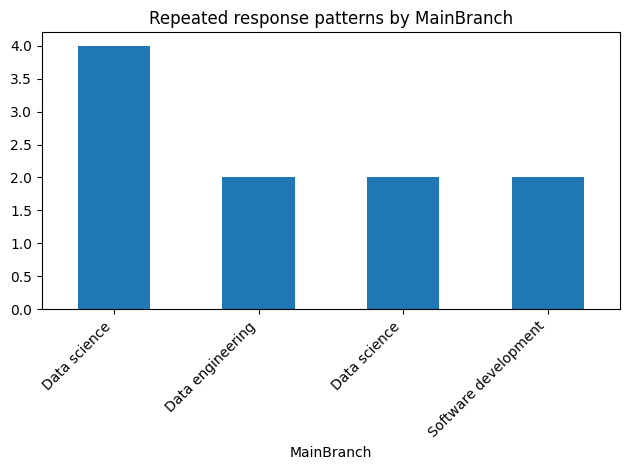


Repeated patterns:
             MainBranch          Employment               RemoteWork  count
1          Data science  Employed full-time  Less than half the time      4
0      Data engineering  Employed full-time             All the time      2
2          Data science  Employed part-time  More than half the time      2
3  Software development  Employed full-time             All the time      2


In [10]:
# Task 3: Visualize shared response patterns (use pattern_counts from earlier)
import matplotlib.pyplot as plt
shared = pattern_counts[pattern_counts['count'] > 1].sort_values('count', ascending=False)
if shared.empty:
    print('No repeated response patterns to visualize')
else:
    ax = shared.plot(kind='bar', x='MainBranch', y='count', title='Repeated response patterns by MainBranch', legend=False)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print('\nRepeated patterns:')
    print(shared)


### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


### Task 4: Evaluate Duplicate Handling Strategy
- Columns that best define uniqueness: `RespondentID` is the primary unique identifier; when absent, a combination of `MainBranch`, `Employment`, `RemoteWork`, `Country`, and `Age` can be used to detect near-duplicates.
- Removing rows based on a subset (e.g., response-pattern columns) is useful when you want to remove repeated answer patterns, but may remove legitimate multiple respondents who coincidentally gave the same answers. Use subset-based removal only when you have a reason to treat identical responses as duplicates (e.g., same respondent submitted multiple times).
- Recommended approach: keep the earliest or the latest record per `RespondentID` if present; otherwise inspect high-count patterns and decide per-case.

## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


## Verify and Document Duplicate Removal Process
1. Identify exact duplicates using `df.duplicated()` and count them.
2. For near-duplicates, define a subset of columns (`RespondentID` or a set of response-pattern columns) to assess uniqueness.
3. Remove duplicates using `df.drop_duplicates(subset=..., keep='first')` after deciding which record to keep.
4. Document which columns were used and why, plus the number of rows removed.

2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Documentation Note
- When removing duplicates in production data pipelines, preserve a copy of the original dataset and log the filtering criteria.
- Include rationale for choosing `subset` columns and the `keep` policy (first/last).
- Store a summary table showing counts before and after deduplication.

### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
